In [1]:
library(tidyr)
library(stringr)
library(ggplot2)
library(dplyr)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
king.df <- read.table('/tscc/lustre/ddn/scratch/welison/Liver_concordance/concordance_out/joint_king_v2.king', sep='\t')
dim(king.df)
head(king.df)

[1] 181 181

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.500000000,0.000789561,-0.02271980,0.01030230,-0.000312159,0.00838295,-0.019337000,-0.01220520,0.00366386,0.00140713,⋯,0.00854701,-0.02148410,0.00145945,0.00209790,-0.03863920,-0.00446775,-0.03162390,0.00854701,-0.00101010,-0.00936286
2,0.000789561,0.500000000,0.00202866,0.01624830,0.017132800,0.01297590,0.037029600,0.02879320,0.00857466,-0.01156790,⋯,0.01395370,-0.00687398,-0.01192480,0.00526187,-0.00656364,0.02921460,-0.01226140,0.01830060,0.01180710,0.02185770
3,-0.022719800,0.002028660,0.50000000,-0.00379288,-0.005737840,-0.01146680,0.035420200,0.02371790,-0.01409760,-0.01804800,⋯,-0.01559230,0.00687814,-0.04429170,-0.02143900,0.01309030,-0.00663077,0.00665415,-0.01140760,-0.02217710,-0.01498960
4,0.010302300,0.016248300,-0.00379288,0.50000000,0.011467200,0.01142230,-0.001497250,-0.01454110,0.01334840,-0.00476992,⋯,0.01569770,-0.01346270,-0.00338491,0.00948573,-0.04703760,0.01255810,-0.02514560,0.01083920,0.01878340,0.01050390
5,-0.000312159,0.017132800,-0.00573784,0.01146720,0.500000000,0.01199320,0.000764034,-0.00302189,0.00997689,0.00184401,⋯,0.02193590,-0.00283786,-0.00720735,0.00200031,-0.03668500,0.01265530,-0.01469910,0.01384410,0.01192500,-0.00122718
6,0.008382950,0.012975900,-0.01146680,0.01142230,0.011993200,0.50000000,0.004556980,0.00673387,0.01080630,-0.00566929,⋯,0.02370100,-0.01582280,-0.00597324,0.01709470,-0.03676240,0.02020050,-0.02154170,0.01329910,0.00864207,0.00660693


In [3]:
names.vect <- read.table('/tscc/lustre/ddn/scratch/welison/Liver_concordance/concordance_out/joint_king_v2.king.id') %>%
    unlist() %>% unname()
names.vect

[1] "HL150001_seq"                         
  [2] "HL150009_seq"                         
  [3] "HL150013_seq"                         
  [4] "HL150015_seq"                         
  [5] "HL160017_seq"                         
  [6] "HL160022_seq"                         
  [7] "HL160026_seq"                         
  [8] "HL160029_seq"                         
  [9] "HL160030_seq"                         
 [10] "HL160032_seq"                         
 [11] "HL160035_seq"                         
 [12] "HL160037_seq"                         
 [13] "HL160040_seq"                         
 [14] "HL160041_seq"                         
 [15] "HL160042_seq"                         
 [16] "HL170044_seq"                         
 [17] "HL170046_seq"                         
 [18] "HL170047_seq"                         
 [19] "HL170048_seq"                         
 [20] "HL170049_seq"                         
 [21] "HL170052_seq"                         
 [22] "HL170055_seq"                         
 [23] "HL170058_seq"                         
 [24] "HL170060_seq"                         
 [25] "HL170062_seq"                         
 [26] "HL170064_seq"                         
 [27] "HL170065_seq"                         
 [28] "HL170066_seq"                         
 [29] "HL180071_seq"                         
 [30] "HL180809_seq"                         
 [31] "HL181010_seq"                         
 [32] "HL181029_seq"                         
 [33] "HL181031_seq"                         
 [34] "HL190114_seq"                         
 [35] "HL190214_seq"                         
 [36] "HL190215_seq"                         
 [37] "HL190326_seq"                         
 [38] "HL190603_seq"                         
 [39] "HL190606_seq"                         
 [40] "HL190624_seq"                         
 [41] "HL190827_seq"                         
 [42] "HL190909_seq"                         
 [43] "HL191002_seq"                         
 [44] "HL191025_seq"                         
 [45] "HL191216_seq"                         
 [46] "HL200115_seq"                         
 [47] "HL200212_seq"                         
 [48] "HL200525_seq"                         
 [49] "HL200529_seq"                         
 [50] "HL200615_seq"                         
 [51] "HL200707_seq"                         
 [52] "HL200805_seq"                         
 [53] "HL200925_seq"                         
 [54] "HL201024_seq"                         
 [55] "HL201120_seq"                         
 [56] "HL210120_seq"                         
 [57] "HL210207_seq"                         
 [58] "HL210521_seq"                         
 [59] "HL210614_seq"                         
 [60] "HL210621_seq"                         
 [61] "HL210706_seq"                         
 [62] "HL210726_seq"                         
 [63] "HL210727_seq"                         
 [64] "HL210806_seq"                         
 [65] "HL211001_seq"                         
 [66] "HL211025_seq"                         
 [67] "HL211106_seq"                         
 [68] "HL211122_seq"                         
 [69] "HL220127_seq"                         
 [70] "HL220210_seq"                         
 [71] "HL220216_seq"                         
 [72] "HL220402_seq"                         
 [73] "HL220405_seq"                         
 [74] "HL220613_seq"                         
 [75] "HL220628_seq"                         
 [76] "HL220825_seq"                         
 [77] "HL221006_seq"                         
 [78] "HL221019_seq"                         
 [79] "HL221119_seq"                         
 [80] "HL221201_seq"                         
 [81] "HL221215_seq"                         
 [82] "HL230212_seq"                         
 [83] "HL230302_seq"                         
 [84] "HL230316_seq"                         
 [85] "HL230324_seq"                         
 [86] "HL230325_seq"                         
 [87] "HL170044_array"                       


In [4]:
colnames(king.df) <- names.vect
rownames(king.df) <- names.vect

dim(king.df)
head(king.df)

[1] 181 181

,HL150001_seq,HL150009_seq,HL150013_seq,HL150015_seq,HL160017_seq,HL160022_seq,HL160026_seq,HL160029_seq,HL160030_seq,HL160032_seq,⋯,HL170066_array,HL180071_array,HL170060_array,HL211122_array,HL221215_array,HL210806_array,HL190606_array,HL191216_array,HL210120_array,HL181010_array
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL150001_seq,0.500000000,0.000789561,-0.02271980,0.01030230,-0.000312159,0.00838295,-0.019337000,-0.01220520,0.00366386,0.00140713,⋯,0.00854701,-0.02148410,0.00145945,0.00209790,-0.03863920,-0.00446775,-0.03162390,0.00854701,-0.00101010,-0.00936286
HL150009_seq,0.000789561,0.500000000,0.00202866,0.01624830,0.017132800,0.01297590,0.037029600,0.02879320,0.00857466,-0.01156790,⋯,0.01395370,-0.00687398,-0.01192480,0.00526187,-0.00656364,0.02921460,-0.01226140,0.01830060,0.01180710,0.02185770
HL150013_seq,-0.022719800,0.002028660,0.50000000,-0.00379288,-0.005737840,-0.01146680,0.035420200,0.02371790,-0.01409760,-0.01804800,⋯,-0.01559230,0.00687814,-0.04429170,-0.02143900,0.01309030,-0.00663077,0.00665415,-0.01140760,-0.02217710,-0.01498960
HL150015_seq,0.010302300,0.016248300,-0.00379288,0.50000000,0.011467200,0.01142230,-0.001497250,-0.01454110,0.01334840,-0.00476992,⋯,0.01569770,-0.01346270,-0.00338491,0.00948573,-0.04703760,0.01255810,-0.02514560,0.01083920,0.01878340,0.01050390
HL160017_seq,-0.000312159,0.017132800,-0.00573784,0.01146720,0.500000000,0.01199320,0.000764034,-0.00302189,0.00997689,0.00184401,⋯,0.02193590,-0.00283786,-0.00720735,0.00200031,-0.03668500,0.01265530,-0.01469910,0.01384410,0.01192500,-0.00122718
HL160022_seq,0.008382950,0.012975900,-0.01146680,0.01142230,0.011993200,0.50000000,0.004556980,0.00673387,0.01080630,-0.00566929,⋯,0.02370100,-0.01582280,-0.00597324,0.01709470,-0.03676240,0.02020050,-0.02154170,0.01329910,0.00864207,0.00660693


In [5]:
names.vect.sort <- sort(names.vect) 
names.vect.sort <- names.vect.sort[!str_detect(names.vect.sort,'^\\d')]

names.vect.sort

[1] "HL150001_array" "HL150001_seq"   "HL150009_array" "HL150009_seq"  
  [5] "HL150013_array" "HL150013_seq"   "HL150015_array" "HL150015_seq"  
  [9] "HL160017_array" "HL160017_seq"   "HL160022_array" "HL160022_seq"  
 [13] "HL160026_array" "HL160026_seq"   "HL160029_array" "HL160029_seq"  
 [17] "HL160030_array" "HL160030_seq"   "HL160032_array" "HL160032_seq"  
 [21] "HL160035_array" "HL160035_seq"   "HL160037_array" "HL160037_seq"  
 [25] "HL160040_array" "HL160040_seq"   "HL160041_array" "HL160041_seq"  
 [29] "HL160042_array" "HL160042_seq"   "HL170044_array" "HL170044_seq"  
 [33] "HL170046_array" "HL170046_seq"   "HL170047_array" "HL170047_seq"  
 [37] "HL170048_array" "HL170048_seq"   "HL170049_array" "HL170049_seq"  
 [41] "HL170052_array" "HL170052_seq"   "HL170055_array" "HL170055_seq"  
 [45] "HL170058_array" "HL170058_seq"   "HL170060_array" "HL170060_seq"  
 [49] "HL170062_array" "HL170062_seq"   "HL170064_array" "HL170064_seq"  
 [53] "HL170065_array" "HL170065_seq"   "HL170066_array" "HL170066_seq"  
 [57] "HL180071_array" "HL180071_seq"   "HL180809_array" "HL180809_seq"  
 [61] "HL181010_array" "HL181010_seq"   "HL181029_array" "HL181029_seq"  
 [65] "HL181031_array" "HL181031_seq"   "HL190114_array" "HL190114_seq"  
 [69] "HL190214_array" "HL190214_seq"   "HL190215_array" "HL190215_seq"  
 [73] "HL190326_array" "HL190326_seq"   "HL190603_array" "HL190603_seq"  
 [77] "HL190606_array" "HL190606_seq"   "HL190624_array" "HL190624_seq"  
 [81] "HL190827_array" "HL190827_seq"   "HL190909_array" "HL190909_seq"  
 [85] "HL191002_array" "HL191002_seq"   "HL191025_array" "HL191025_seq"  
 [89] "HL191216_array" "HL191216_seq"   "HL200115_array" "HL200115_seq"  
 [93] "HL200212_array" "HL200212_seq"   "HL200525_array" "HL200525_seq"  
 [97] "HL200529_array" "HL200529_seq"   "HL200615_array" "HL200615_seq"  
[101] "HL200707_array" "HL200707_seq"   "HL200805_array" "HL200805_seq"  
[105] "HL200925_array" "HL200925_seq"   "HL201024_array" "HL201024_seq"  
[109] "HL201120_array" "HL201120_seq"   "HL210120_array" "HL210120_seq"  
[113] "HL210207_array" "HL210207_seq"   "HL210521_array" "HL210521_seq"  
[117] "HL210614_array" "HL210614_seq"   "HL210621_array" "HL210621_seq"  
[121] "HL210706_array" "HL210706_seq"   "HL210726_array" "HL210726_seq"  
[125] "HL210727_array" "HL210727_seq"   "HL210806_array" "HL210806_seq"  
[129] "HL211001_array" "HL211001_seq"   "HL211025_array" "HL211025_seq"  
[133] "HL211106_array" "HL211106_seq"   "HL211122_array" "HL211122_seq"  
[137] "HL220127_array" "HL220127_seq"   "HL220210_array" "HL220210_seq"  
[141] "HL220216_array" "HL220216_seq"   "HL220402_array" "HL220402_seq"  
[145] "HL220405_array" "HL220405_seq"   "HL220613_array" "HL220613_seq"  
[149] "HL220628_array" "HL220628_seq"   "HL220825_array" "HL220825_seq"  
[153] "HL221006_array" "HL221006_seq"   "HL221019_array" "HL221019_seq"  
[157] "HL221119_array" "HL221119_seq"   "HL221201_array" "HL221201_seq"  
[161] "HL221215_array" "HL221215_seq"   "HL230212_array" "HL230212_seq"  
[165] "HL230302_array" "HL230302_seq"   "HL230316_array" "HL230316_seq"  
[169] "HL230324_array" "HL230324_seq"   "HL230325_array" "HL230325_seq"

In [6]:
king.df[names.vect.sort,names.vect.sort]

,HL150001_array,HL150001_seq,HL150009_array,HL150009_seq,HL150013_array,HL150013_seq,HL150015_array,HL150015_seq,HL160017_array,HL160017_seq,⋯,HL230212_array,HL230212_seq,HL230302_array,HL230302_seq,HL230316_array,HL230316_seq,HL230324_array,HL230324_seq,HL230325_array,HL230325_seq
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL150001_array,0.500000000,0.493901000,-0.005476150,-0.001827850,-0.035697600,-0.02694390,-0.001094950,0.00763359,-0.00396147,-0.003082080,⋯,-0.028041000,-0.028831100,-0.023225100,-0.017857100,-0.203640,-0.184028,-2.64098e-03,0.002400060,0.002679820,0.002176620
HL150001_seq,0.493901000,0.500000000,-0.004234650,0.000789561,-0.032136200,-0.02271980,0.000587222,0.01030230,-0.00186480,-0.000312159,⋯,-0.025019400,-0.025171700,-0.020085500,-0.014409100,-0.199393,-0.179413,-1.16550e-04,0.005587030,0.005516710,0.005715400
HL150009_array,-0.005476150,-0.004234650,0.500000000,0.489201000,-0.021332900,-0.00104485,-0.010597500,0.01437980,0.00656581,0.011044600,⋯,-0.008406260,-0.005518930,-0.001917870,0.007502630,-0.178303,-0.159256,-5.44065e-03,0.015331800,0.008849560,0.007375420
HL150009_seq,-0.001827850,0.000789561,0.489201000,0.500000000,-0.017373900,0.00202866,-0.008348720,0.01624830,0.01154980,0.017132800,⋯,-0.001882780,0.000531567,0.018894400,0.033883100,-0.173723,-0.154510,4.12882e-05,0.019372200,0.015236500,0.014325200
HL150013_array,-0.035697600,-0.032136200,-0.021332900,-0.017373900,0.500000000,0.48955200,-0.035390300,-0.02629690,-0.02853470,-0.027477700,⋯,-0.000272501,0.001444410,-0.026354700,-0.022168600,-0.194539,-0.173908,-3.15712e-02,-0.026332400,-0.037293700,-0.037829200
HL150013_seq,-0.026943900,-0.022719800,-0.001044850,0.002028660,0.489552000,0.50000000,-0.024711200,-0.00379288,-0.01165990,-0.005737840,⋯,0.009685820,0.014930200,-0.008077480,-0.005602240,-0.186231,-0.165126,-2.27384e-02,-0.009269850,-0.017395900,-0.017822500
HL150015_array,-0.001094950,0.000587222,-0.010597500,-0.008348720,-0.035390300,-0.02471120,0.500000000,0.49111600,-0.01134050,-0.009350940,⋯,-0.041764400,-0.040711400,-0.027217300,-0.021784800,-0.205862,-0.183350,-6.64790e-03,-0.001825690,-0.003636790,-0.003521130
HL150015_seq,0.007633590,0.010302300,0.014379800,0.016248300,-0.026296900,-0.00379288,0.491116000,0.50000000,0.00687785,0.011467200,⋯,-0.027356700,-0.024089300,-0.002868220,0.005103880,-0.196466,-0.174766,7.78902e-03,0.022223100,0.015637200,0.015461500
HL160017_array,-0.003961470,-0.001864800,0.006565810,0.011549800,-0.028534700,-0.01165990,-0.011340500,0.00687785,0.50000000,0.492234000,⋯,-0.012286900,-0.012604100,-0.008140070,-0.008358800,-0.206119,-0.186060,6.94552e-03,0.014570700,0.014705900,0.015139900


In [74]:
gtcheck.df <- read.table('/tscc/lustre/ddn/scratch/welison/Liver_concordance/concordance_out/gtcheck_results_v2.txt', sep='\t', col.names = c('DC','ID1','ID2','Discordance','HWE','Sites')) %>%
    filter(!str_detect(ID1,'^\\d')) %>%
    filter(!str_detect(ID2,'^\\d'))

dim(gtcheck.df)
head(gtcheck.df)
table(gtcheck.df$Sites)

[1] 7396    6

,DC,ID1,ID2,Discordance,HWE,Sites
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>
1,DC,HL150001_seq,HL170044_array,31978,0,69023
2,DC,HL150001_seq,HL200529_array,33069,0,69023
3,DC,HL150001_seq,HL230212_array,32764,0,69023
4,DC,HL150001_seq,HL220405_array,31411,0,69023
5,DC,HL150001_seq,HL160017_array,31001,0,69023
6,DC,HL150001_seq,HL170064_array,34421,0,69023



14432 49822 56070 56467 60140 61154 61245 63624 63781 64141 64230 64245 64638 
   86    86    86    86    86    86    86    86    86    86    86    86    86 
64809 65022 65050 65377 65479 65612 65625 66171 66176 66511 66599 66627 66686 
   86    86    86    86    86    86    86    86    86    86    86    86    86 
66762 66850 67124 67228 67468 67572 67615 67798 67802 67830 67896 68005 68109 
   86    86    86    86    86    86    86    86    86    86    86    86    86 
68205 68217 68229 68243 68244 68277 68299 68405 68414 68429 68437 68463 68474 
   86    86    86    86    86    86    86    86    86    86    86    86    86 
68514 68552 68554 68576 68595 68651 68667 68722 68778 68826 68841 68851 68866 
   86    86    86    86    86    86    86    86    86    86    86    86   172 
68869 68872 68876 68877 68885 68896 68950 68956 68981 68987 69019 69020 69022 
   86    86    86    86    86    86    86    86    86    86    86    86    86 
69023 69030 69031 69035 69037 69061 69076 
   86   

In [11]:
gtcheck.df %>%
    mutate(Discordance.prop= Discordance / Sites)

DC,ID1,ID2,Discordance,HWE,Sites,Discordance.prop
<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
DC,HL150001_seq,HL170044_array,31978,0,69023,0.4632948
DC,HL150001_seq,HL200529_array,33069,0,69023,0.4791012
DC,HL150001_seq,HL230212_array,32764,0,69023,0.4746824
DC,HL150001_seq,HL220405_array,31411,0,69023,0.4550802
DC,HL150001_seq,HL160017_array,31001,0,69023,0.4491401
DC,HL150001_seq,HL170064_array,34421,0,69023,0.4986888
DC,HL150001_seq,HL220402_array,30795,0,69023,0.4461556
DC,HL150001_seq,HL150015_array,31617,0,69023,0.4580647
DC,HL150001_seq,HL181029_array,33031,0,69023,0.4785506


In [12]:
gtcheck.df %>%
    mutate(Discordance.prop= Discordance / Sites) %>%
    select(ID1, ID2, Discordance.prop) %>%
    pivot_wider(names_from = ID2, values_from = Discordance.prop) %>%
    tibble::column_to_rownames('ID1')

,HL170044_array,HL200529_array,HL230212_array,HL220405_array,HL160017_array,HL170064_array,HL220402_array,HL150015_array,HL181029_array,HL190114_array,⋯,HL170066_array,HL180071_array,HL170060_array,HL211122_array,HL221215_array,HL210806_array,HL190606_array,HL191216_array,HL210120_array,HL181010_array
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL150001_seq,0.46329484,0.4791012,0.4746824,0.4550802,0.449140142,0.498688843,0.4461556,0.458064703,0.4785506,0.4585283,⋯,0.451458210,0.47094447,0.44317112,0.4566884,0.4820857,0.4568622,0.4794199,0.4473292,0.4566304,0.4620199
HL150009_seq,0.45889084,0.4747316,0.4699794,0.4631202,0.457814278,0.502537603,0.4512473,0.453415767,0.4758543,0.4693796,⋯,0.457968072,0.47374735,0.45813725,0.4640891,0.4701178,0.4577066,0.4766233,0.4642275,0.4629202,0.4686106
HL150013_seq,0.47363287,0.4651588,0.4562275,0.4771231,0.473754801,0.505730659,0.4790587,0.473876730,0.4832805,0.4760410,⋯,0.475019813,0.45959581,0.47924160,0.4754008,0.4490337,0.4790130,0.4573401,0.4762848,0.4722764,0.4773365
HL150015_seq,0.45212531,0.4788059,0.4711955,0.4541016,0.454942332,0.500265479,0.4522580,0.008834548,0.4737028,0.4511224,⋯,0.459971682,0.47573818,0.44305478,0.4507832,0.4725967,0.4650158,0.4760037,0.4513731,0.4507979,0.4606354
HL160017_seq,0.45665495,0.4648012,0.4744286,0.4508466,0.007362124,0.504733831,0.4462870,0.456553306,0.4695641,0.4600238,⋯,0.450817530,0.46817007,0.44798594,0.4540557,0.4787268,0.4629135,0.4669213,0.4519066,0.4483635,0.4653385
HL160022_seq,0.45114075,0.4788250,0.4699322,0.4566222,0.447831475,0.503156207,0.4517676,0.455762082,0.4731832,0.4430935,⋯,0.452219550,0.47077775,0.44689846,0.4429186,0.4679496,0.4553102,0.4649756,0.4531817,0.4445805,0.4623369
HL160026_seq,0.47003709,0.4599619,0.4612382,0.4763135,0.476523672,0.504151714,0.4724846,0.474511629,0.4848571,0.4738359,⋯,0.478760942,0.45933122,0.46577276,0.4639109,0.4589108,0.4723494,0.4650971,0.4752474,0.4744966,0.4793015
HL160029_seq,0.45944292,0.4586016,0.4603913,0.4686205,0.466754363,0.499304037,0.4620738,0.470746593,0.4746165,0.4724903,⋯,0.469706472,0.46985943,0.46066660,0.4645212,0.4499442,0.4643529,0.4532175,0.4582345,0.4672438,0.4657601
HL160030_seq,0.46342455,0.4764898,0.4825434,0.4628003,0.458212964,0.501691225,0.4493867,0.463264862,0.4785222,0.4510561,⋯,0.460724396,0.47768019,0.45477245,0.4624374,0.4815417,0.4619293,0.4813094,0.4569355,0.4560354,0.4617551


In [14]:
gtcheck.df.wide <- gtcheck.df %>%
    mutate(Discordance.prop= Discordance / Sites) %>%
    select(ID1, ID2, Discordance.prop) %>%
    pivot_wider(names_from = ID2, values_from = Discordance.prop) %>%
    tibble::column_to_rownames('ID1')

sort.on.row <- rownames(gtcheck.df.wide) %>% sort()
sort.on.col <- colnames(gtcheck.df.wide) %>% sort()

gtcheck.df.wide <- gtcheck.df.wide[sort.on.row,sort.on.col]

dim(gtcheck.df.wide)
head(gtcheck.df.wide)

[1] 86 86

,HL150001_array,HL150009_array,HL150013_array,HL150015_array,HL160017_array,HL160022_array,HL160026_array,HL160029_array,HL160030_array,HL160032_array,⋯,HL221006_array,HL221019_array,HL221119_array,HL221201_array,HL221215_array,HL230212_array,HL230302_array,HL230316_array,HL230324_array,HL230325_array
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL150001_seq,0.00572273,0.4569781,0.47766686,0.458064703,0.449140142,0.454355794,0.4781884,0.4713936,0.4591223,0.4484882,⋯,0.4574707,0.4761311,0.4571375,0.4733640,0.4820857,0.4746824,0.4669603,0.5094679,0.4538777,0.4506469
HL150009_seq,0.45827566,0.0135954,0.47097905,0.453415767,0.457814278,0.460767125,0.4677494,0.4581219,0.4716404,0.4717942,⋯,0.4614746,0.4673649,0.4595983,0.4734551,0.4701178,0.4699794,0.4718864,0.5037218,0.4563994,0.4579835
HL150013_seq,0.47847955,0.4681003,0.01114125,0.473876730,0.473754801,0.477366945,0.4563799,0.4569896,0.4764068,0.4752332,⋯,0.4763610,0.4559379,0.4773974,0.4536823,0.4490337,0.4562275,0.4697769,0.5129549,0.4760715,0.4748826
HL150015_seq,0.45775936,0.4505914,0.47376184,0.008834548,0.454942332,0.453983658,0.4745140,0.4687620,0.4618153,0.4579511,⋯,0.4559305,0.4673018,0.4495885,0.4718445,0.4725967,0.4711955,0.4714315,0.5053096,0.4518451,0.4472877
HL160017_seq,0.44920570,0.4565243,0.47371707,0.456553306,0.007362124,0.448014986,0.4787268,0.4663985,0.4586588,0.4535329,⋯,0.4456335,0.4725990,0.4510789,0.4695786,0.4787268,0.4744286,0.4730927,0.5085238,0.4516162,0.4469985
HL160022_seq,0.45424594,0.4587652,0.47733800,0.455762082,0.447831475,0.007813981,0.4716379,0.4573074,0.4574386,0.4566951,⋯,0.4503098,0.4757198,0.4559079,0.4757781,0.4679496,0.4699322,0.4705299,0.5089584,0.4496683,0.4462424


In [15]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.4.3”


In [26]:
pool.composition

donor_demux,batch
<chr>,<fct>
HL160029,firstPR
HL160042,firstPR
HL170046,firstPR
HL170049,firstPR
HL170060,firstPR
HL190326,firstPR
HL191025,firstPR
HL200707,firstPR
HL200805,firstPR


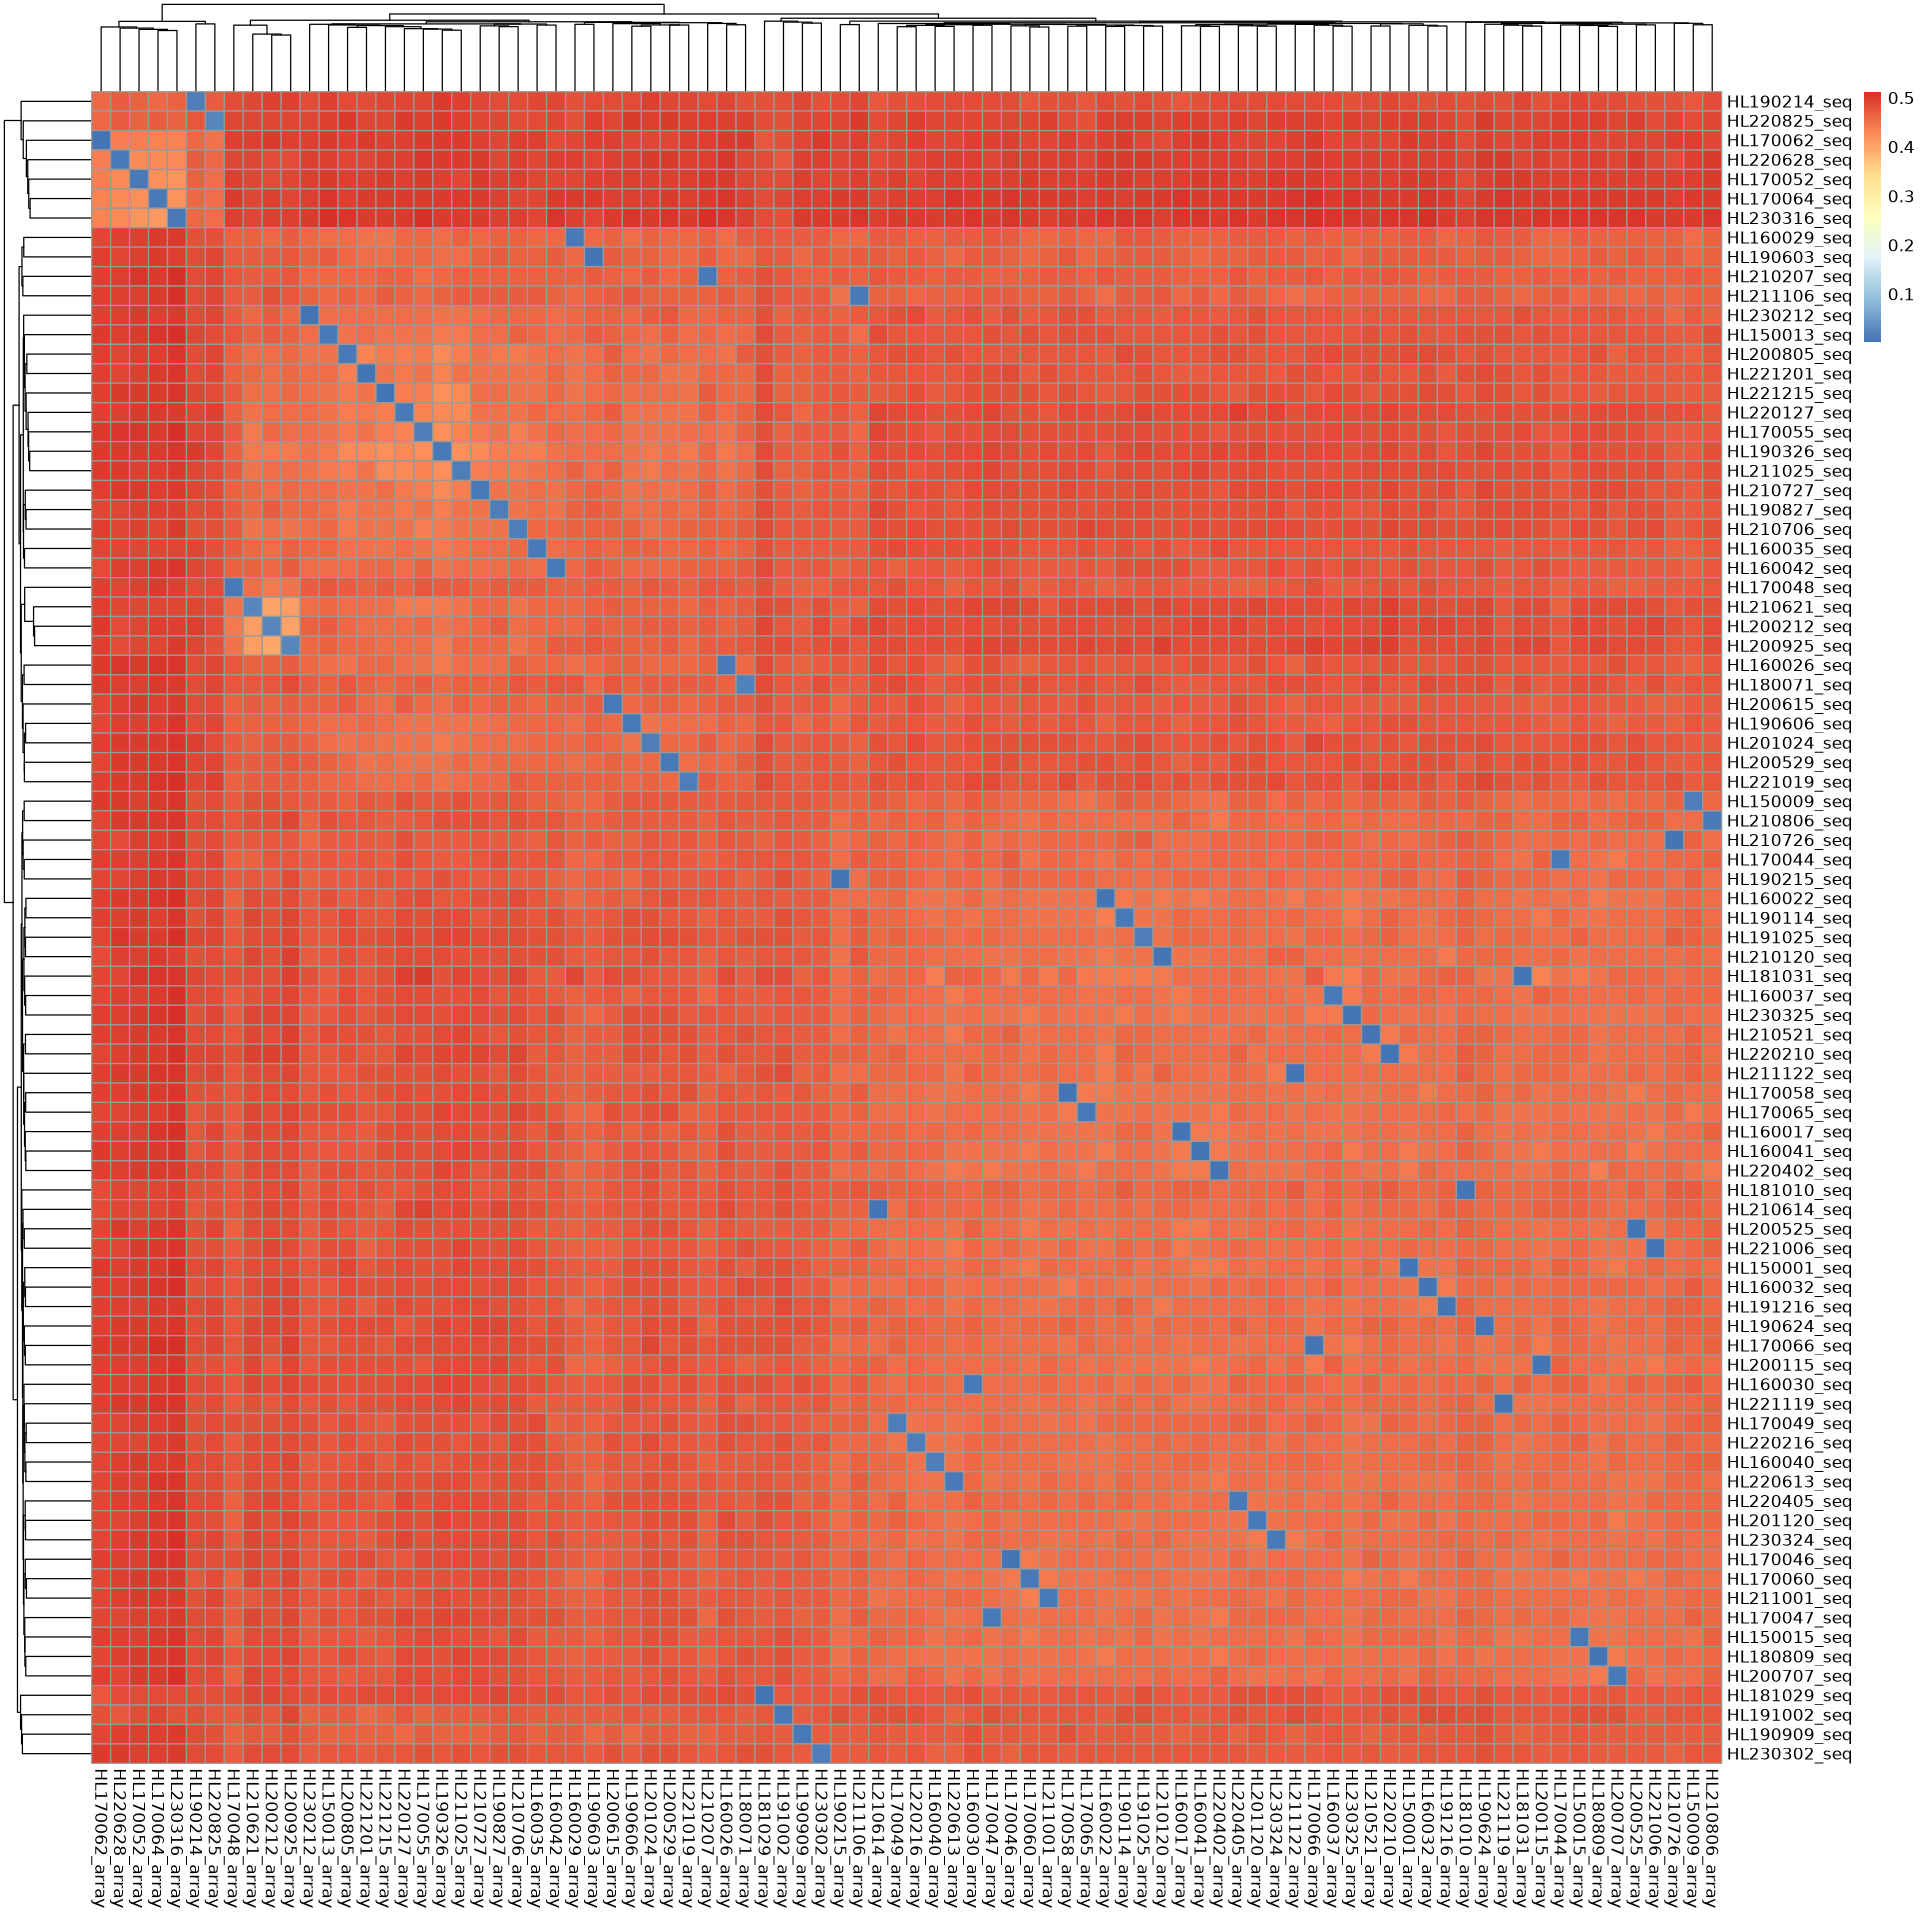

In [25]:
options(repr.plot.width=16, repr.plot.height=16)
pheatmap(gtcheck.df.wide)
options(repr.plot.width=8, repr.plot.height=8)

In [27]:
pool.composition <- read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', sep='\t', header=T) %>%
    select(donor_demux, batch) %>%
    mutate(batch=factor(batch, levels=c('firstPR','secondPR','thirdPR','fourthPR'))) %>%
    arrange(batch) %>%
    mutate(array=paste0(donor_demux, '_array')) %>%
    mutate(seq=paste0(donor_demux, '_seq'))
pool.composition

donor_demux,batch,array,seq
<chr>,<fct>,<chr>,<chr>
HL160029,firstPR,HL160029_array,HL160029_seq
HL160042,firstPR,HL160042_array,HL160042_seq
HL170046,firstPR,HL170046_array,HL170046_seq
HL170049,firstPR,HL170049_array,HL170049_seq
HL170060,firstPR,HL170060_array,HL170060_seq
HL190326,firstPR,HL190326_array,HL190326_seq
HL191025,firstPR,HL191025_array,HL191025_seq
HL200707,firstPR,HL200707_array,HL200707_seq
HL200805,firstPR,HL200805_array,HL200805_seq


In [30]:
table(pool.composition$batch)


 firstPR secondPR  thirdPR fourthPR 
      15       24       24       23 

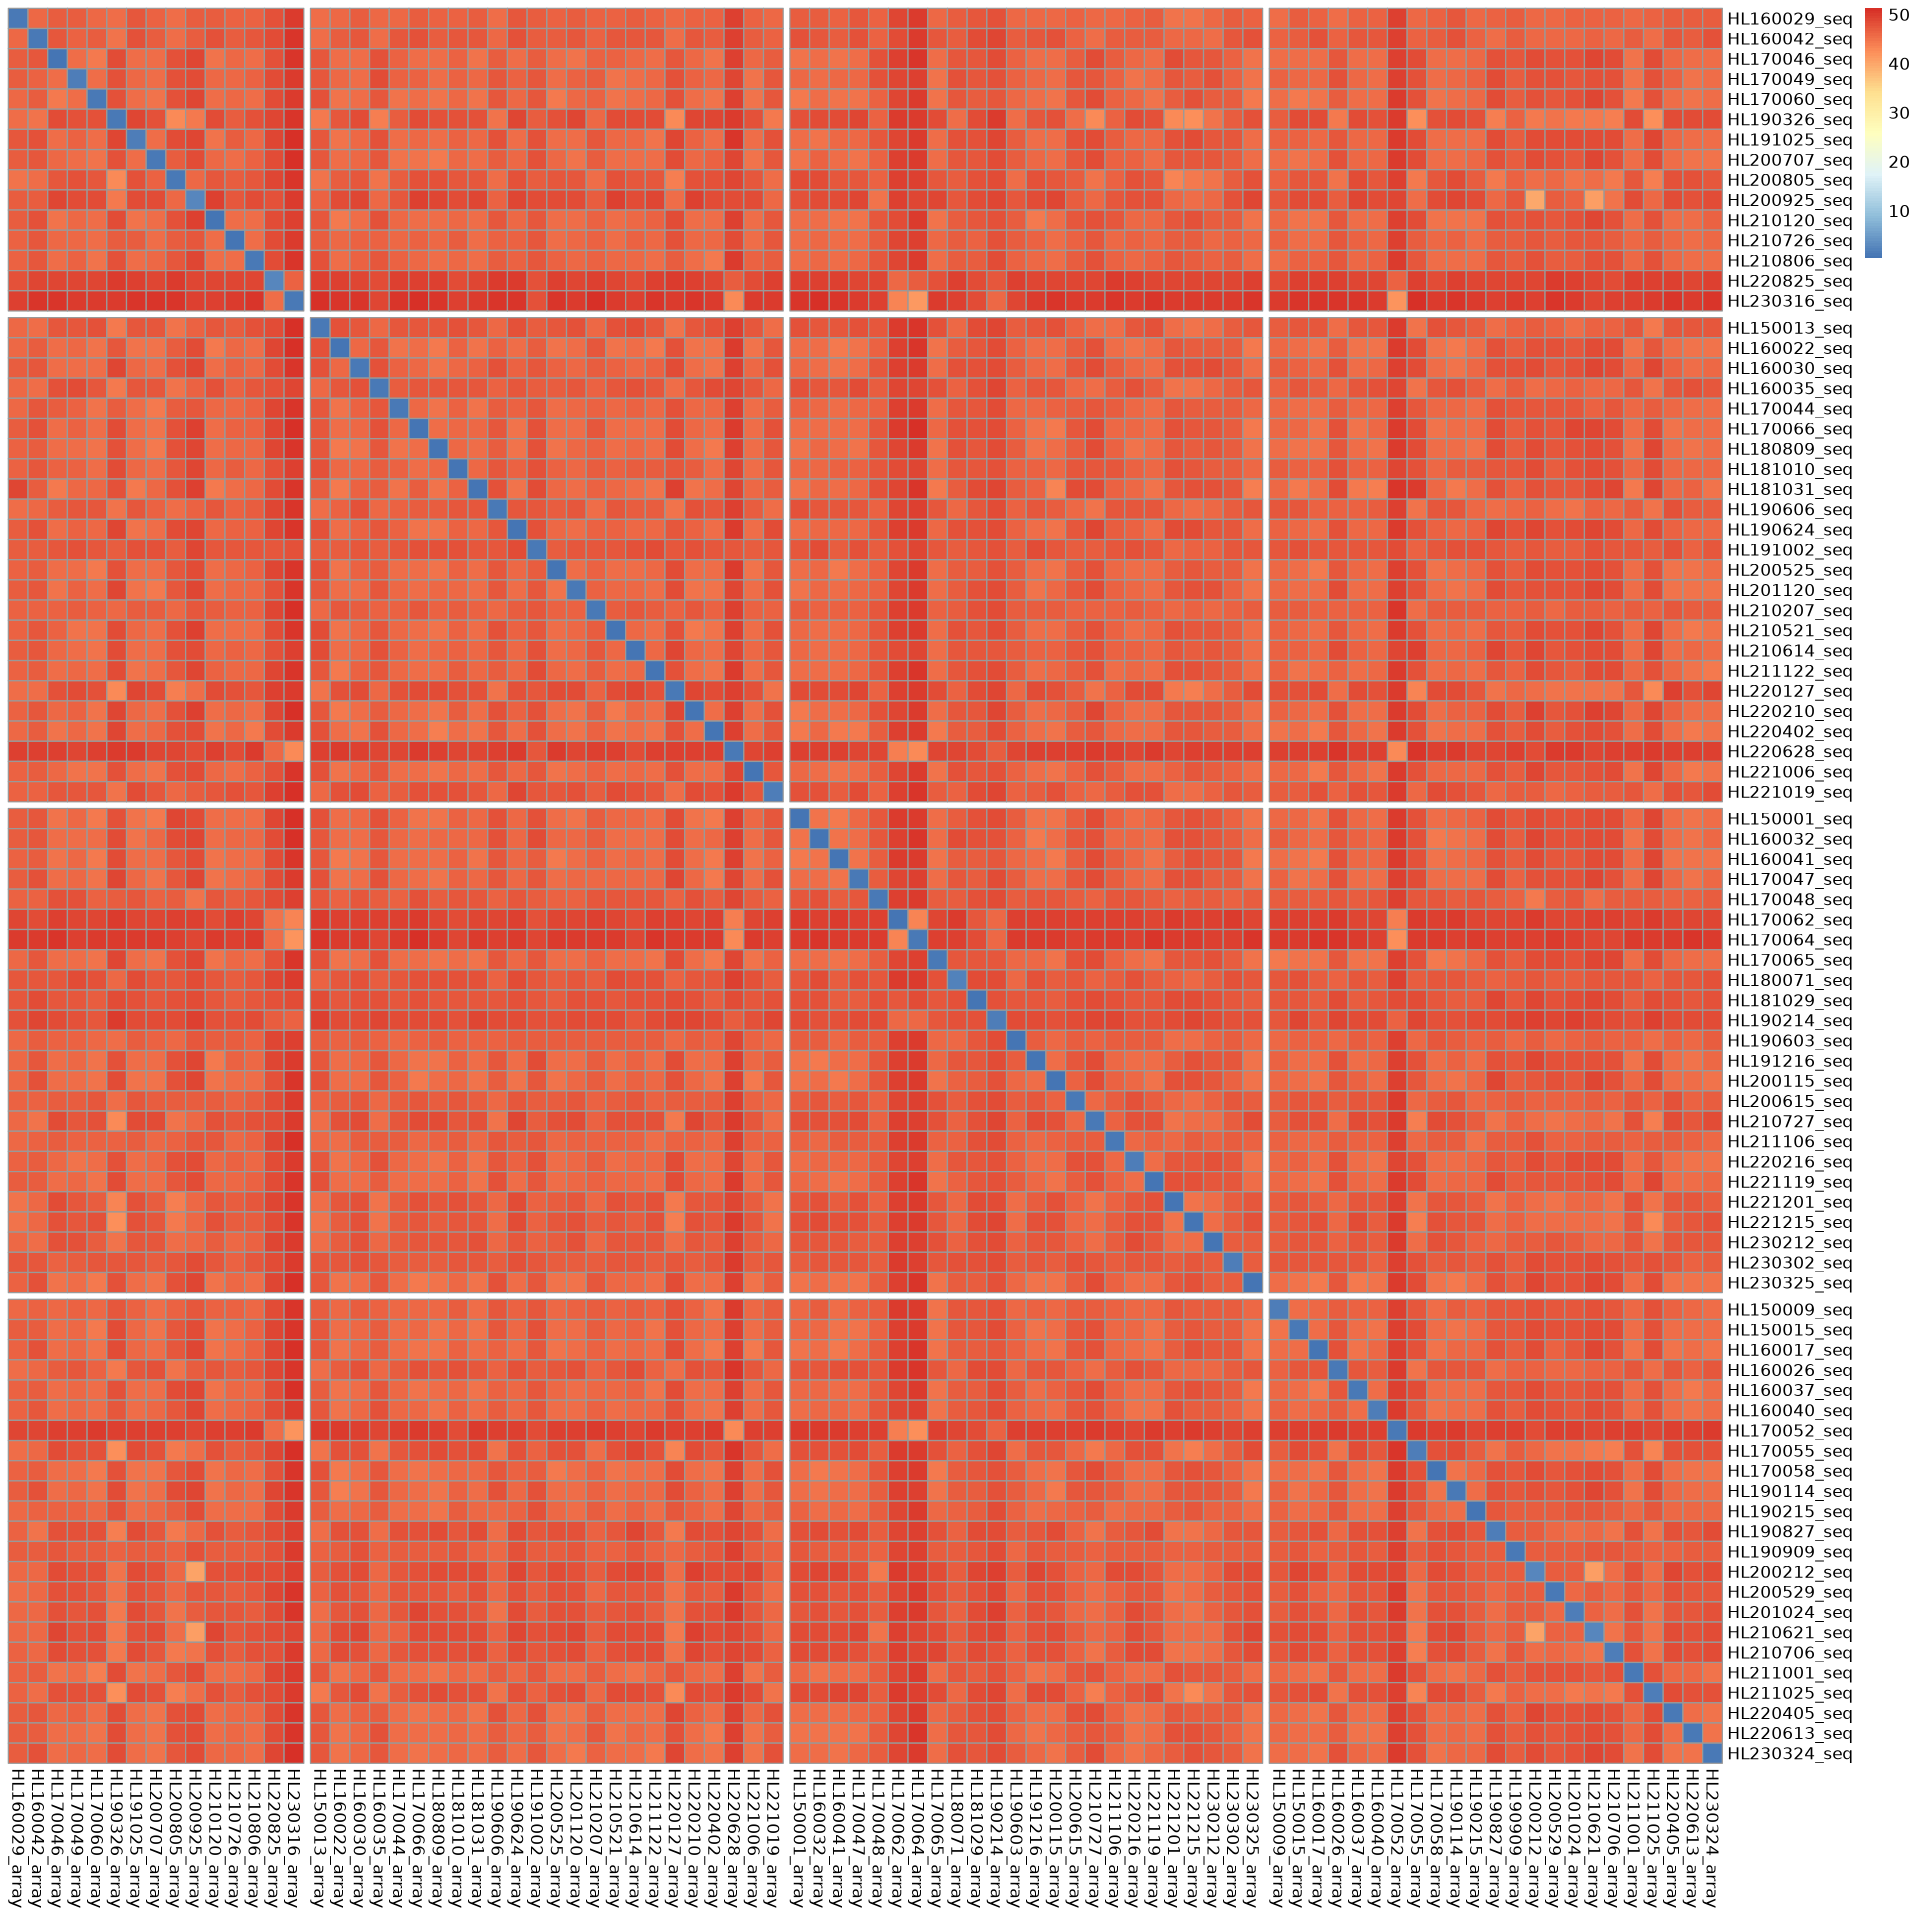

In [32]:
options(repr.plot.width=16, repr.plot.height=16)
pheatmap(gtcheck.df.wide[pool.composition$seq,pool.composition$array] * 100, 
         cluster_rows = F, cluster_cols = F, gaps_col = c(15, 39, 63), gaps_row = c(15, 39, 63))
options(repr.plot.width=8, repr.plot.height=8)

In [38]:
pool.composition

donor_demux,batch,array,seq
<chr>,<fct>,<chr>,<chr>
HL160029,firstPR,HL160029_array,HL160029_seq
HL160042,firstPR,HL160042_array,HL160042_seq
HL170046,firstPR,HL170046_array,HL170046_seq
HL170049,firstPR,HL170049_array,HL170049_seq
HL170060,firstPR,HL170060_array,HL170060_seq
HL190326,firstPR,HL190326_array,HL190326_seq
HL191025,firstPR,HL191025_array,HL191025_seq
HL200707,firstPR,HL200707_array,HL200707_seq
HL200805,firstPR,HL200805_array,HL200805_seq


Saving 7 x 4 in image


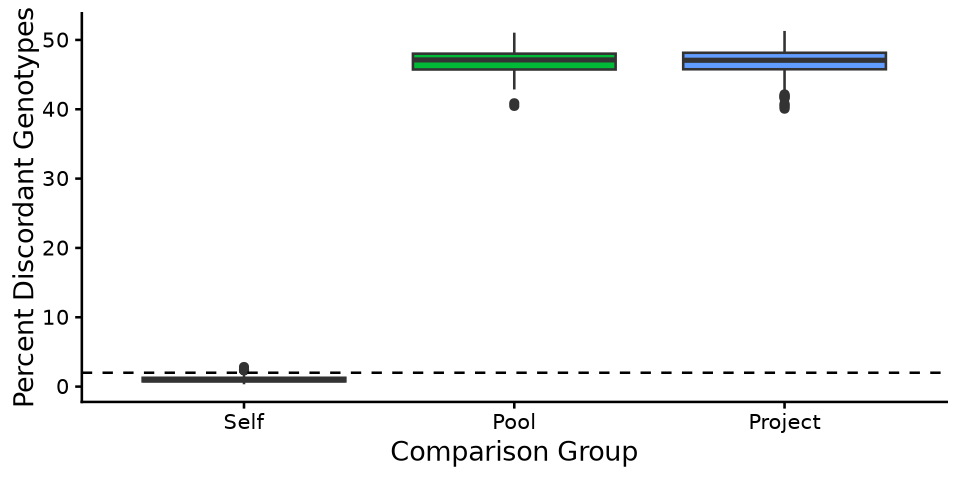

In [61]:
options(repr.plot.height=4)
p1 <- gtcheck.df.wide %>%
    tibble::rownames_to_column('seq') %>%
    pivot_longer(contains('array'), names_to = 'array', values_to = 'Discordance') %>%
    mutate(seq=str_remove(seq, '_seq')) %>%
    mutate(array=str_remove(array, '_array')) %>%
    mutate(Discordance = Discordance * 100) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(seq==donor_demux)) %>%
    rename(batch_seq=batch) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(array==donor_demux)) %>%
    rename(batch_array=batch) %>%
    mutate(group=ifelse(seq==array, 'Self',
                       ifelse(batch_seq==batch_array, 'Pool', 'Project'))) %>%
    mutate(group=factor(group, c('Self','Pool','Project'))) %>%
    ggplot(aes(x=group, y=Discordance, fill=group)) +
        geom_boxplot() +
        geom_hline(yintercept = 2, linetype = "dashed") +
        theme_classic(base_size=16) +
        labs(x='Comparison Group', y='Percent Discordant Genotypes') +
        theme(legend.position='none')

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/plots/reviewer.comments.panels/260616_WE_Multiome_GT_concordance.pdf', height=4)

Warning message in geom_violin(outlier.shape = NA):
“Ignoring unknown parameters: `outlier.shape`”


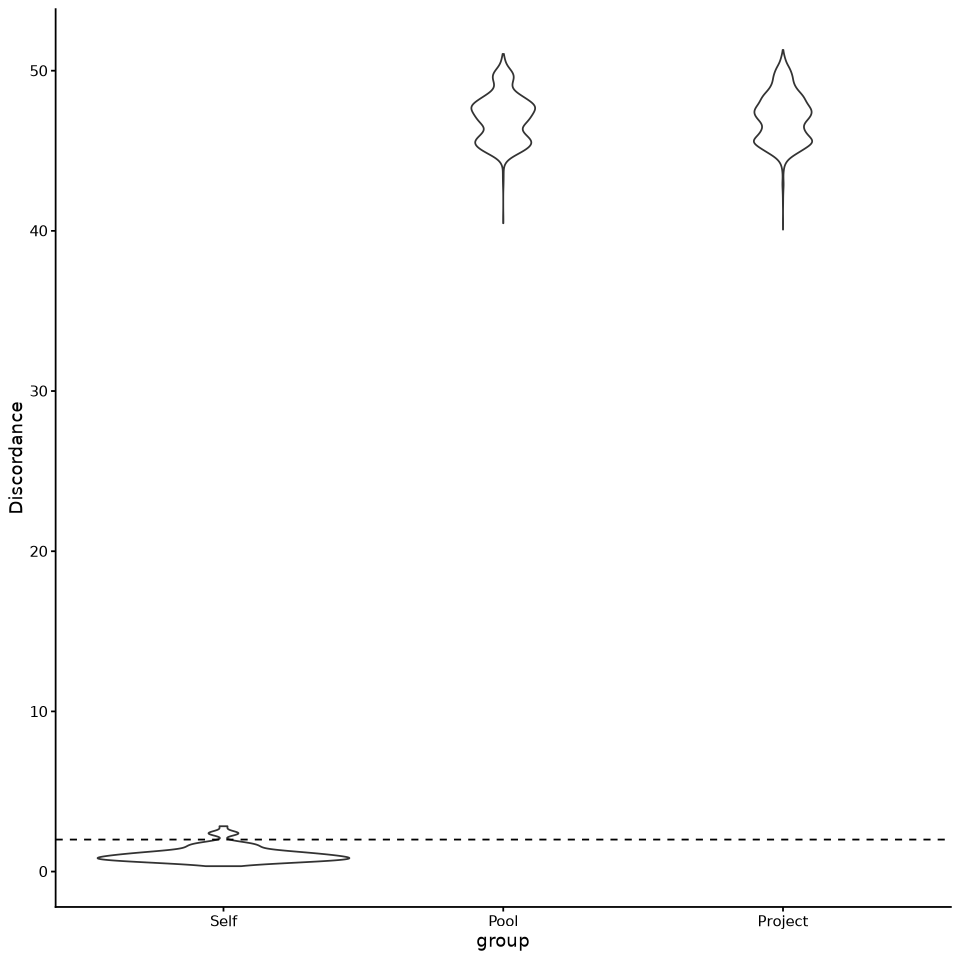

In [53]:
gtcheck.df.wide %>%
    tibble::rownames_to_column('seq') %>%
    pivot_longer(contains('array'), names_to = 'array', values_to = 'Discordance') %>%
    mutate(seq=str_remove(seq, '_seq')) %>%
    mutate(array=str_remove(array, '_array')) %>%
    mutate(Discordance = Discordance * 100) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(seq==donor_demux)) %>%
    rename(batch_seq=batch) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(array==donor_demux)) %>%
    rename(batch_array=batch) %>%
    mutate(group=ifelse(seq==array, 'Self',
                       ifelse(batch_seq==batch_array, 'Pool', 'Project'))) %>%
    mutate(group=factor(group, c('Self','Pool','Project'))) %>%
    ggplot(aes(x=group, y=Discordance)) +
        geom_violin(outlier.shape = NA) +
        geom_hline(yintercept = 2, linetype = "dashed") +
        theme_classic()

In [88]:
gtcheck.df.DPT <- read.table('/tscc/lustre/ddn/scratch/welison/Liver_concordance/DPT/concordance_out/gtcheck_results_v2.txt', sep='\t', col.names = c('DC','ID1','ID2','Discordance','HWE','Sites')) %>%
    filter(!str_detect(ID1,'^\\d')) %>%
    filter(!str_detect(ID2,'^\\d')) %>%
    mutate(seq=str_remove(ID1,'_seq')) %>%
    mutate(array=str_remove(ID2,'_array')) %>%
    mutate(Discordance=(Discordance * 100) / Sites) %>%
    mutate(modality='Paired-Tag') %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(seq==donor_demux)) %>%
    rename(batch_seq=batch) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(array==donor_demux)) %>%
    rename(batch_array=batch) %>%
    mutate(group=ifelse(seq==array, 'Self',
                       ifelse(batch_seq==batch_array, 'Pool', 'Project'))) %>%
    mutate(group=factor(group, c('Self','Pool','Project'))) %>%
    select(seq, array, Discordance, batch_seq, batch_array, group, modality)

dim(gtcheck.df.DPT)
head(gtcheck.df.DPT)

[1] 7396    7

,seq,array,Discordance,batch_seq,batch_array,group,modality
,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<chr>
1,HL150001,HL170044,41.54930,thirdPR,secondPR,Project,Paired-Tag
2,HL150001,HL200529,42.53521,thirdPR,fourthPR,Project,Paired-Tag
3,HL150001,HL230212,44.64789,thirdPR,thirdPR,Pool,Paired-Tag
4,HL150001,HL220405,43.66197,thirdPR,fourthPR,Project,Paired-Tag
5,HL150001,HL160017,42.11268,thirdPR,fourthPR,Project,Paired-Tag
6,HL150001,HL170064,45.07042,thirdPR,thirdPR,Pool,Paired-Tag


Saving 7 x 4 in image


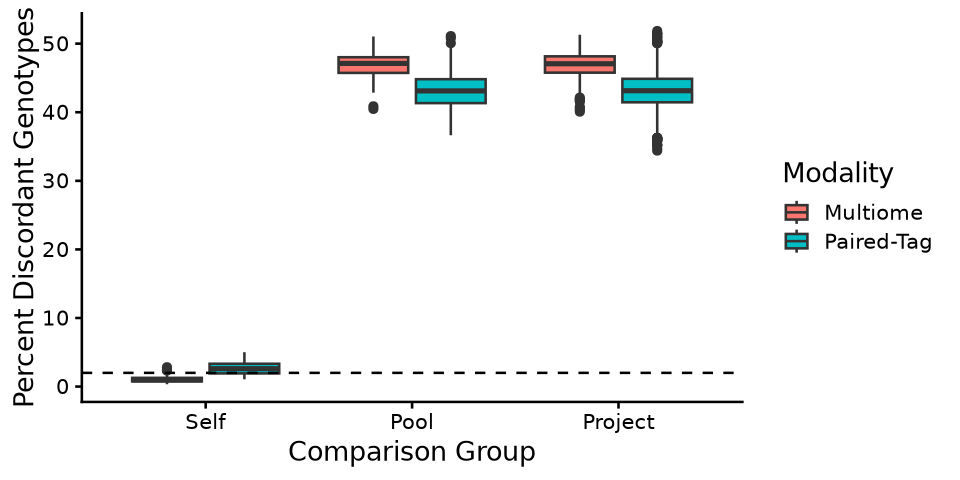

In [90]:
options(repr.plot.width=8, repr.plot.height=4)
p1 <- gtcheck.df.wide %>%
    tibble::rownames_to_column('seq') %>%
    pivot_longer(contains('array'), names_to = 'array', values_to = 'Discordance') %>%
    mutate(seq=str_remove(seq, '_seq')) %>%
    mutate(array=str_remove(array, '_array')) %>%
    mutate(Discordance = Discordance * 100) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(seq==donor_demux)) %>%
    rename(batch_seq=batch) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(array==donor_demux)) %>%
    rename(batch_array=batch) %>%
    mutate(group=ifelse(seq==array, 'Self',
                       ifelse(batch_seq==batch_array, 'Pool', 'Project'))) %>%
    mutate(group=factor(group, c('Self','Pool','Project'))) %>%
    mutate(modality='Multiome') %>%
    bind_rows(gtcheck.df.DPT)  %>%
    ggplot(aes(x=group, y=Discordance, fill=modality)) +
        geom_boxplot() +
        geom_hline(yintercept = 2, linetype = "dashed") +
        theme_classic(base_size=16) +
        labs(x='Comparison Group', y='Percent Discordant Genotypes', fill='Modality')

p1

options(repr.plot.width=8, repr.plot.height=8)

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/plots/reviewer.comments.panels/260616_WE_Multiome_DPT_GT_concordance.pdf', height=4)

In [84]:
gtcheck.df.DPT <- read.table('/tscc/lustre/ddn/scratch/welison/Liver_concordance/DPT/concordance_out/gtcheck_results_v2.txt', sep='\t', col.names = c('DC','ID1','ID2','Discordance','HWE','Sites')) %>%
    filter(!str_detect(ID1,'^\\d')) %>%
    filter(!str_detect(ID2,'^\\d'))

gtcheck.df.wide.DPT <- gtcheck.df.DPT %>%
    mutate(Discordance.prop= Discordance / Sites) %>%
    select(ID1, ID2, Discordance.prop) %>%
    pivot_wider(names_from = ID2, values_from = Discordance.prop) %>%
    tibble::column_to_rownames('ID1')

sort.on.row <- rownames(gtcheck.df.wide.DPT) %>% sort()
sort.on.col <- colnames(gtcheck.df.wide.DPT) %>% sort()

gtcheck.df.wide.DPT <- gtcheck.df.wide.DPT[sort.on.row,sort.on.col]

dim(gtcheck.df.wide.DPT)
head(gtcheck.df.wide.DPT)

[1] 86 86

,HL150001_array,HL150009_array,HL150013_array,HL150015_array,HL160017_array,HL160022_array,HL160026_array,HL160029_array,HL160030_array,HL160032_array,⋯,HL221006_array,HL221019_array,HL221119_array,HL221201_array,HL221215_array,HL230212_array,HL230302_array,HL230316_array,HL230324_array,HL230325_array
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HL150001_seq,0.03943662,0.38732394,0.43098592,0.40422535,0.42112676,0.43239437,0.4549296,0.4154930,0.3943662,0.3887324,⋯,0.4521127,0.3971831,0.3915493,0.4183099,0.4070423,0.4464789,0.4338028,0.4549296,0.4126761,0.3802817
HL150009_seq,0.37096774,0.02284946,0.43145161,0.40591398,0.38172043,0.42338710,0.4502688,0.4408602,0.4086022,0.4059140,⋯,0.3830645,0.4032258,0.4381720,0.4368280,0.4193548,0.4489247,0.3857527,0.4435484,0.4072581,0.4086022
HL150013_seq,0.43671766,0.42976356,0.03337969,0.43949930,0.46036161,0.43532684,0.4464534,0.4325452,0.4631433,0.4102921,⋯,0.4381085,0.3908206,0.4561892,0.4102921,0.4019471,0.4492350,0.4255911,0.4742698,0.4492350,0.4617524
HL150015_seq,0.40053763,0.38978495,0.42876344,0.02150538,0.40994624,0.40725806,0.4327957,0.3978495,0.4260753,0.4059140,⋯,0.3897849,0.4314516,0.4018817,0.4341398,0.4274194,0.4381720,0.4166667,0.4704301,0.4247312,0.4032258
HL160017_seq,0.39867550,0.39867550,0.43178808,0.40132450,0.02649007,0.40132450,0.4529801,0.4079470,0.4264901,0.3814570,⋯,0.4172185,0.4688742,0.4264901,0.4251656,0.4397351,0.4304636,0.4304636,0.4807947,0.4198675,0.4026490
HL160022_seq,0.47407407,0.45925926,0.49444444,0.46481481,0.46481481,0.04259259,0.4925926,0.4611111,0.4814815,0.4629630,⋯,0.4185185,0.4833333,0.4981481,0.4481481,0.4611111,0.4055556,0.4351852,0.5185185,0.4370370,0.4703704


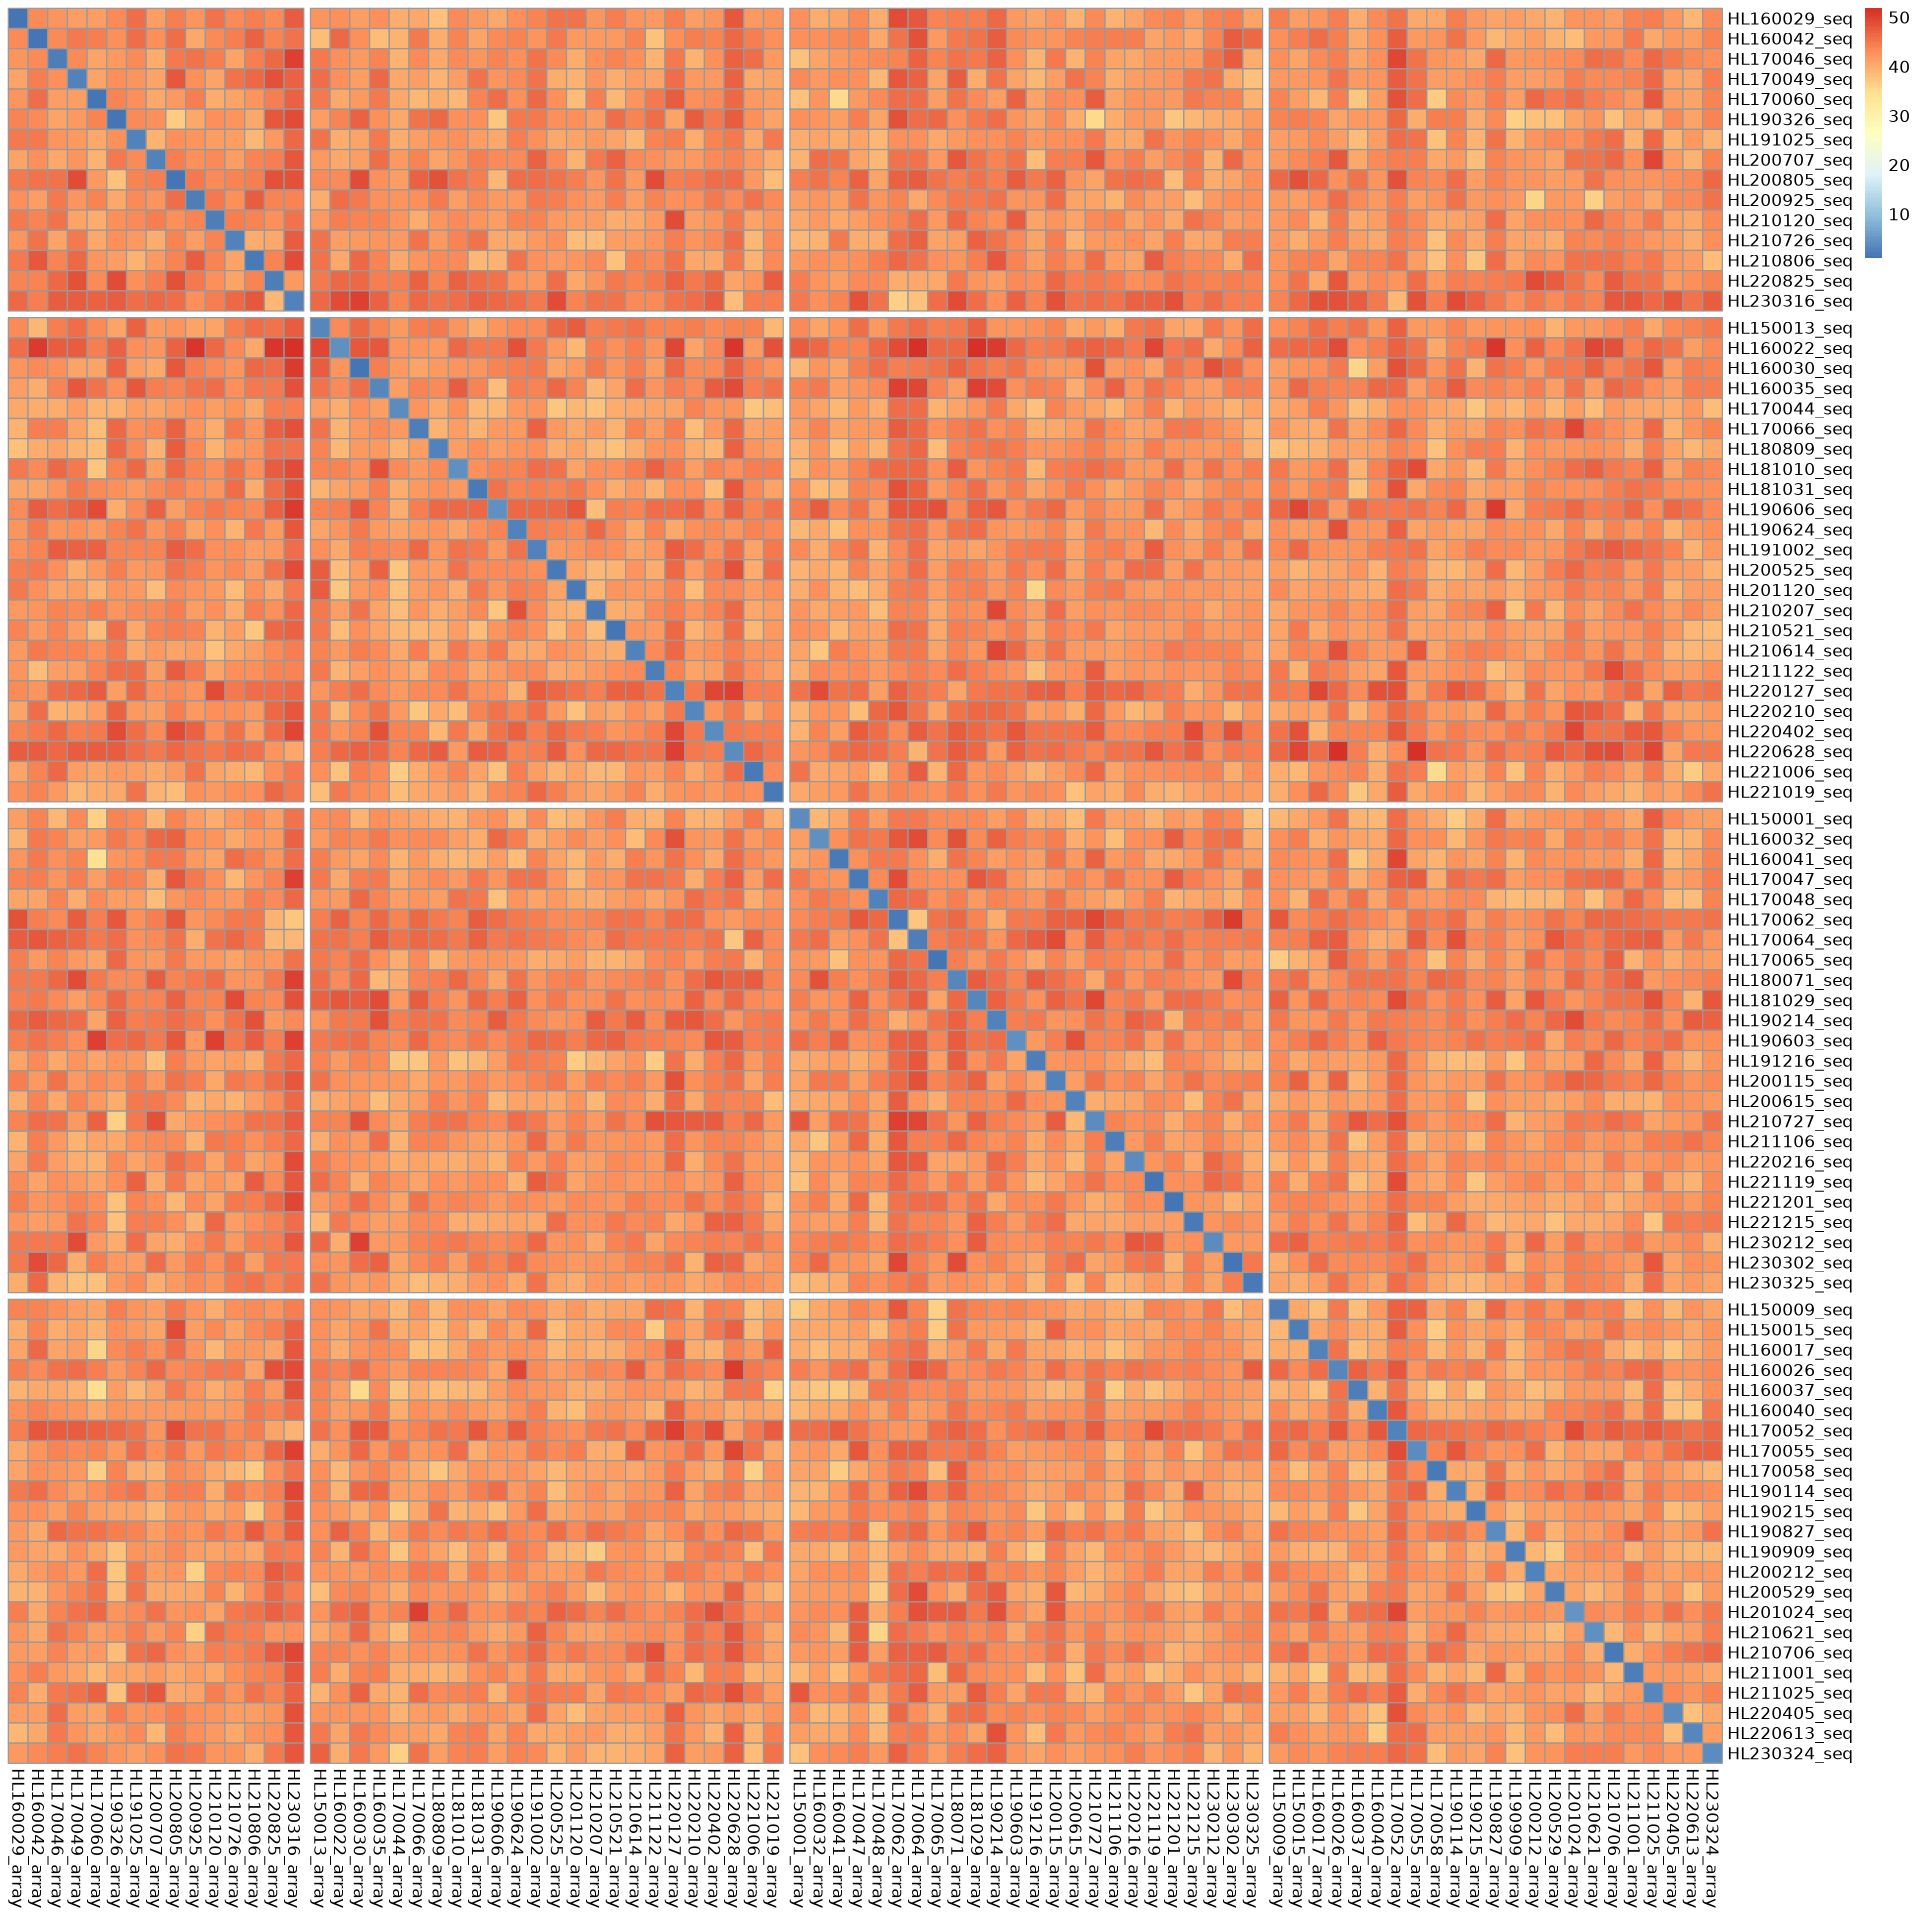

In [86]:
options(repr.plot.width=16, repr.plot.height=16)
pheatmap(gtcheck.df.wide.DPT[pool.composition$seq,pool.composition$array] * 100,
         cluster_rows = F, cluster_cols = F, gaps_col = c(15, 39, 63), gaps_row = c(15, 39, 63))
options(repr.plot.width=8, repr.plot.height=8)

In [ ]:
options(repr.plot.height=4)
p1 <- gtcheck.df.wide %>%
    tibble::rownames_to_column('seq') %>%
    pivot_longer(contains('array'), names_to = 'array', values_to = 'Discordance') %>%
    mutate(seq=str_remove(seq, '_seq')) %>%
    mutate(array=str_remove(array, '_array')) %>%
    mutate(Discordance = Discordance * 100) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(seq==donor_demux)) %>%
    rename(batch_seq=batch) %>%
    left_join(select(pool.composition, donor_demux, batch), join_by(array==donor_demux)) %>%
    rename(batch_array=batch) %>%
    mutate(group=ifelse(seq==array, 'Self',
                       ifelse(batch_seq==batch_array, 'Pool', 'Project'))) %>%
    mutate(group=factor(group, c('Self','Pool','Project'))) %>%
    ggplot(aes(x=group, y=Discordance, fill=group)) +
        geom_boxplot() +
        geom_hline(yintercept = 2, linetype = "dashed") +
        theme_classic(base_size=16) +
        labs(x='Comparison Group', y='Percent Discordant Genotypes') +
        theme(legend.position='none')

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/plots/reviewer.comments.panels/260616_WE_Multiome_GT_concordance.pdf', height=4)